In [51]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

#Loading data
df = pd.read_csv(url)

#Exploring the data
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

In [52]:
#Check for missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [53]:
#Dropping the unnecessary features
df = df.drop(columns=['PassengerId', 'Cabin', 'Name', 'Ticket'])
print(df.shape)
print(df.isnull().sum())
df.head()

(891, 8)
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


<Axes: >

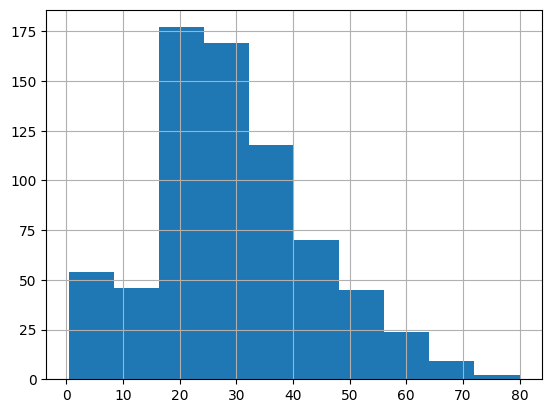

In [54]:
#Visualizihg age to check for outliers
df['Age'].hist()

In [55]:
#Working on missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

#Encoding 'Embarked' using get_dummies()
df = pd.get_dummies(df, columns=['Embarked', 'Sex'], drop_first=True)
print(df.head())

   Survived  Pclass   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S  \
0         0       3  22.0      1      0   7.2500       False        True   
1         1       1  38.0      1      0  71.2833       False       False   
2         1       3  26.0      0      0   7.9250       False        True   
3         1       1  35.0      1      0  53.1000       False        True   
4         0       3  35.0      0      0   8.0500       False        True   

   Sex_male  
0      True  
1     False  
2     False  
3     False  
4      True  


In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#Determining the features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

#Splitting Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42,
stratify=y)

#Standardizing the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Training the model
model = LogisticRegression()
model.fit(X_train,y_train)

#Predicting
y_pred = model.predict(X_test)

#Model evaluation
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
classification = classification_report(y_test, y_pred)

print(f"Accuracy Score: {accuracy * 100:.2f}")
print(f"\nConfusion Matrix:\n{cm}")
print(f"\nClassification Report:\n{classification}")

Accuracy Score: 80.45

Confusion Matrix:
[[98 12]
 [23 46]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



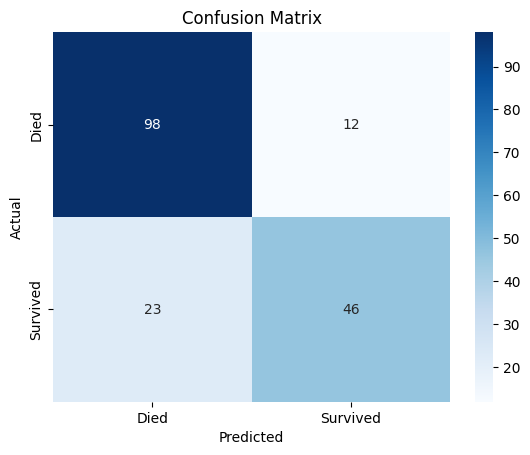

In [57]:
#Visualizing the data
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, fmt='d', annot=True,
cmap="Blues", xticklabels=['Died', 'Survived'],
yticklabels=['Died', 'Survived'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [58]:
#Predicting new passengers
new_passengers = pd.DataFrame({
'Pclass': [1, 2, 3],
'Age': [19, 30, 40],
'SibSp': [1, 0, 0],
'Parch': [0, 2, 3],
'Fare': [80, 60, 20],
'Embarked_Q': [False, False, True],
'Embarked_S': [True, False, False],
'Sex_male': [0, 0, 1]
})

new_passengers = scaler.transform(new_passengers)

y_predi = model.predict(new_passengers)
y_prob = model.predict_proba(new_passengers)

for i, (p, pr) in enumerate(zip(y_predi, y_prob)):
    case = "die" if p == 0 else "survive"
    perc = round(pr.max(), 2) * 100
    print(f"There is a {perc}% chance that passenger {i + 1} would {case}.")

There is a 94.0% chance that passenger 1 would survive.
There is a 84.0% chance that passenger 2 would survive.
There is a 91.0% chance that passenger 3 would die.
